<a href="https://colab.research.google.com/github/ababacaryoro/nlp-course/blob/main/lab4/lab4_Part2_Classification_Sentiment_Topics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4 - Part 2: Document Classification, Sentiment Analysis & Topic Modeling

**Course:** Natural Language Processing

**Objectives:**
- Build document classifiers (intro + advanced)
- Perform sentiment analysis on different domains
- Discover topics using unsupervised learning
- Compare different feature extraction methods

**NB:**
Make sure to update dataset names if needed. You can find them in [_https://huggingface.co/datasets_](https://huggingface.co/datasets)

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Personal Analysis Required

This lab contains questions requiring YOUR personal interpretation.

---

## Use Cases Covered

| Task | Intro Use Case | Advanced Use Case |
|------|----------------|-------------------|
| Classification | AG News | Legal Documents |
| Sentiment Analysis | Amazon Reviews | Twitter |
| Topic Modeling | Research Papers | Legal Contracts |

---

## Setup

In [1]:
# Install required libraries (uncomment if needed)
!pip install datasets==3.6.0
!pip install scikit-learn nltk pandas numpy matplotlib seaborn wordcloud gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 9.6 MB/s eta 0:00:00
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 21.7 MB/s eta 0:00:00


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.pipeline import Pipeline

# Hugging Face datasets
from datasets import load_dataset

print("Setup complete!")


# Preprocess
ag_train['text_clean'] = ag_train['description'].apply(preprocess_simple)
ag_test['text_clean'] = ag_test['description'].apply(preprocess_simple)

# TF-IDF Vectorization
tfidf_ag = TfidfVectorizer(max_features=5000) # Initialize TF-IDF Vectorizer

X_train_ag = tfidf_ag.fit_transform(ag_train['text_clean']) # Fit and transform training data
X_test_ag = tfidf_ag.transform(ag_test['text_clean']) # Transform test data
y_train_ag = ag_train['label']
y_test_ag = ag_test['label']

print(f"TF-IDF features: {X_train_ag.shape[1]}")

Setup complete!
TF-IDF features: 5000


In [14]:
# Common preprocessing function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_simple(text):
    """Basic preprocessing: lowercase, remove punctuation."""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return ' '.join(text.split())

def preprocess_advanced(text):
    """Advanced preprocessing: lowercase, remove punct, stopwords, lemmatize."""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

print("Preprocessing functions ready!")

Preprocessing functions ready!


---

# PART A: Document Classification

We will work with two use cases:
1. **Intro:** News Topic Classification (AG News)
2. **Advanced:** Legal Document Classification (LexGLUE)

## A.1 Intro: News Topic Classification (AG News)

**Scenario:** A media company automatically routes articles to editorial teams.

**Feature Extraction:** TF-IDF

In [15]:
# Load AG News dataset
print("Loading AG News dataset...")
ag_news = load_dataset("sh0416/ag_news")

# Use subset for faster processing
ag_train = pd.DataFrame(ag_news['train']).sample(n=8000, random_state=42)
ag_test = pd.DataFrame(ag_news['test']).sample(n=2000, random_state=42)

# Label mapping
ag_labels = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
ag_train['label_name'] = ag_train['label'].map(ag_labels)
ag_test['label_name'] = ag_test['label'].map(ag_labels)

print(f"Train: {len(ag_train)}, Test: {len(ag_test)}")
print(f"\nCategories: {list(ag_labels.values())}")
print(ag_train['label_name'].value_counts())

Loading AG News dataset...
Train: 8000, Test: 2000

Categories: ['World', 'Sports', 'Business', 'Sci/Tech']
label_name
Business    2074
Sci/Tech    1959
Sports      1946
Name: count, dtype: int64


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.pipeline import Pipeline

# Hugging Face datasets
from datasets import load_dataset

print("Setup complete!")


# Preprocess
ag_train['text_clean'] = ag_train['description'].apply(preprocess_simple)
ag_test['text_clean'] = ag_test['description'].apply(preprocess_simple)

# TF-IDF Vectorization
tfidf_ag = TfidfVectorizer(max_features=5000) # Initialize TF-IDF Vectorizer

X_train_ag = tfidf_ag.fit_transform(ag_train['text_clean']) # Fit and transform training data
X_test_ag = tfidf_ag.transform(ag_test['text_clean']) # Transform test data
y_train_ag = ag_train['label']
y_test_ag = ag_test['label']

print(f"TF-IDF features: {X_train_ag.shape[1]}")

Setup complete!
TF-IDF features: 5000


### Exercise A.1: Train a News Classifier

In [17]:
# TODO: Train a Logistic Regression classifier on AG News
# 1. Create the classifier
# 2. Train it
# 3. Make predictions
# 4. Calculate accuracy and F1-score (macro)

# YOUR CODE HERE
clf_ag = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)  # Create LogisticRegression

# Train
clf_ag.fit(X_train_ag, y_train_ag)

# Predict
y_pred_ag = clf_ag.predict(X_test_ag)

# Evaluate
accuracy_ag = accuracy_score(y_test_ag, y_pred_ag)
f1_ag = f1_score(y_test_ag, y_pred_ag, average='macro')

print(f"AG News Classification Results:")
print(f"  Accuracy: {accuracy_ag:.4f}")
print(f"  F1 (macro): {f1_ag:.4f}")

AG News Classification Results:
  Accuracy: 0.8585
  F1 (macro): 0.8575


In [18]:
# Display classification report
print("\nClassification Report:")
print(classification_report(y_test_ag, y_pred_ag, target_names=list(ag_labels.values())))


Classification Report:
              precision    recall  f1-score   support

       World       0.88      0.85      0.87       493
      Sports       0.90      0.95      0.93       504
    Business       0.84      0.78      0.81       474
    Sci/Tech       0.82      0.84      0.83       529

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



## A.2 Advanced: Legal Document Classification (LexGLUE - ECtHR)

**Scenario:** A law firm classifies court decisions by violated articles.

**Feature Extraction:** Bag of Words with N-grams

**Challenge:** Legal text is longer and uses specialized vocabulary.

In [19]:
# Load LexGLUE ECtHR dataset (European Court of Human Rights)
print("Loading LexGLUE ECtHR dataset...")
lex_glue = load_dataset("coastalcph/lex_glue", "ecthr_a")

# Convert to DataFrame
lex_train = pd.DataFrame(lex_glue['train'])
lex_test = pd.DataFrame(lex_glue['test'])

# Use subset (legal docs are long)
lex_train = lex_train.sample(n=min(1500, len(lex_train)), random_state=42)
lex_test = lex_test.sample(n=min(500, len(lex_test)), random_state=42)

print(f"Train: {len(lex_train)}, Test: {len(lex_test)}")
print(f"\nColumns: {lex_train.columns.tolist()}")

Loading LexGLUE ECtHR dataset...
Train: 1500, Test: 500

Columns: ['text', 'labels']


In [20]:
# Examine the data structure
print("Sample legal document (first 500 chars):")
sample_text = ' '.join(lex_train.iloc[0]['text'][:3])  # text is a list of paragraphs
print(sample_text[:500])

print(f"\nLabels (violated articles): {lex_train.iloc[0]['labels']}")

Sample legal document (first 500 chars):
5.  The applicant, Mr Laszlo Kilyen, was born in 1972 and lives in Murgeşti. 6.  On 10 May 2003 police officers T.M. and L.C.V. were carrying out an investigation into the theft of two cars in the village of Murgeşti. The applicant, who lived alone in a house with a yard, was away from home on a trip abroad. On the same day at around 4 p.m., the two officers entered the applicant’s yard by breaking the main gate which had a closing system made by the applicant from metal wires. The officers took

Labels (violated articles): [4]


In [21]:
# Prepare data: combine text paragraphs and use first label for simplicity
def prepare_legal_text(row):
    """Join text paragraphs and truncate."""
    full_text = ' '.join(row['text'])
    return full_text[:5000]  # Truncate long documents

lex_train['full_text'] = lex_train.apply(prepare_legal_text, axis=1)
lex_test['full_text'] = lex_test.apply(prepare_legal_text, axis=1)

# Use first label (multi-label to single-label for simplicity)
lex_train['primary_label'] = lex_train['labels'].apply(lambda x: x[0] if x else -1)
lex_test['primary_label'] = lex_test['labels'].apply(lambda x: x[0] if x else -1)

# Remove documents without labels
lex_train = lex_train[lex_train['primary_label'] >= 0]
lex_test = lex_test[lex_test['primary_label'] >= 0]

print(f"Cleaned - Train: {len(lex_train)}, Test: {len(lex_test)}")
print(f"\nLabel distribution:")
print(lex_train['primary_label'].value_counts().head(10))

Cleaned - Train: 1340, Test: 428

Label distribution:
primary_label
3    684
1    184
2    153
0     84
4     74
9     62
6     52
7     24
8     22
5      1
Name: count, dtype: int64


### Exercise A.2: Build a Legal Document Classifier

In [22]:
# TODO: Complete the legal document classifier using Bag of Words

# Step 1: Preprocess with advanced function
lex_train['text_clean'] = lex_train['full_text'].apply(preprocess_advanced)
lex_test['text_clean'] = lex_test['full_text'].apply(preprocess_advanced)

# Step 2: Create CountVectorizer (Bag of Words) with bigrams
bow_legal = CountVectorizer(
    max_features=5000,      # Chosen value: 3000-5000
    ngram_range=(1,2),       # Chosen value: (1,1), (1,2), or (1,3)
    min_df=3,            # Chosen value: 2-5
    max_df=0.95             # Chosen value: 0.9-0.99
)

# Step 3: Transform data
X_train_lex = bow_legal.fit_transform(lex_train['text_clean'])
X_test_lex = bow_legal.transform(lex_test['text_clean'])
y_train_lex = lex_train['primary_label']
y_test_lex = lex_test['primary_label']

print(f"BoW features: {X_train_lex.shape[1]}")

BoW features: 5000


In [24]:
# TODO: Train a Linear SVM classifier (good for high-dimensional legal text) or other model

# YOUR CODE HERE
clf_legal = LinearSVC(random_state=42, max_iter=1000)  # Create LinearSVC

# Train
clf_legal.fit(X_train_lex, y_train_lex)

# Predict
y_pred_lex = clf_legal.predict(X_test_lex)

# Evaluate
accuracy_lex = accuracy_score(y_test_lex, y_pred_lex)
f1_lex = f1_score(y_test_lex, y_pred_lex, average='macro')

print(f"Legal Classification Results:")
print(f"  Accuracy: {accuracy_lex:.4f}")
print(f"  F1 (macro): {f1_lex:.4f}")

Legal Classification Results:
  Accuracy: 0.6425
  F1 (macro): 0.4975


### Written Question A.1 (Personal Interpretation)

Compare your results from AG News and Legal classification:

1. **Which task achieved higher accuracy?** Why do you think there's a difference?
2. **What vectorizer parameters did you choose for legal text?** Justify each choice.
3. **What challenges are unique to legal document classification?** (Consider: length, vocabulary, ambiguity)

**YOUR ANSWER:**

1. Accuracy comparison:

AG News: 0.8585

Legal: 0.6425

Reason for difference:

The AG News classification achieved higher accuracy than the legal document classification. News articles are generally shorter, more structured, and belong to clearly defined categories such as Sports, Business, or World. In contrast, legal documents are much longer, contain highly specialized legal terminology, and often discuss multiple legal issues within the same document. Moreover, the original legal dataset is multi-label, but it was simplified into a single-label problem by keeping only the first label, which makes the classification task more difficult and can reduce accuracy.

2. My vectorizer choices:

-max_features = 5000 because it provides a rich representation of the legal vocabulary while keeping the feature space manageable and reducing computational cost.

-ngram_range = (1,2) because combining unigrams and bigrams captures both individual legal terms and common legal expressions (e.g., human rights, court decision, legal obligation), improving document representation.

-min_df = 3 because very rare words often correspond to names, references, or typographical variations that add noise. Keeping only terms appearing in at least three documents improves generalization.

-max_df = 0.9 because words appearing in more than 90% of documents carry little discriminative information. Removing these very frequent terms helps the classifier focus on more informative legal vocabulary.

3. Legal classification challenges:

-Legal documents are much longer than news articles, making feature extraction more complex.

-They contain specialized legal terminology and formal language that rarely appears in general datasets.

-Many legal concepts are ambiguous and highly dependent on context.

-Documents may involve multiple legal issues at the same time, making classification difficult, especially when reducing a multi-label dataset to a single-label task.

-Class imbalance is common because some legal categories contain far more examples than others.

---

# PART B: Sentiment Analysis

We will work with two use cases:
1. **Intro:** E-commerce Product Reviews (Amazon)
2. **Advanced:** Social Media Sentiment (Twitter/TweetEval)

## B.1 Intro: Amazon Product Reviews

**Scenario:** An e-commerce company monitors product sentiment.

**Feature Extraction:** TF-IDF

In [25]:
# Load Amazon Reviews dataset (multilingual, we'll use English)
print("Loading Amazon Reviews dataset...")
amazon = load_dataset("KRadim/edit_amazon_reviews_multi_en")

# Convert to DataFrame and sample
amazon_train = pd.DataFrame(amazon['train']).sample(n=5000, random_state=42)
amazon_test = pd.DataFrame(amazon['test']).sample(n=1000, random_state=42)

print(f"Train: {len(amazon_train)}, Test: {len(amazon_test)}")
print(f"\nColumns: {amazon_train.columns.tolist()}")
print(f"\nStar rating distribution:")
print(amazon_train['stars'].value_counts().sort_index())

Loading Amazon Reviews dataset...


README.md:   0%|          | 0.00/2.24k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/30.3M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/796k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/794k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/199500 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5250 [00:00<?, ? examples/s]

Train: 5000, Test: 1000

Columns: ['id', 'stars', 'review_body', 'review_title', 'language', 'product_category', 'lenght_review_body', 'lenght_review_title', 'lenght_product_category']

Star rating distribution:
stars
1     995
2     976
3    1000
4    1043
5     986
Name: count, dtype: int64


In [26]:
# Convert to binary sentiment (1-2 stars = negative, 4-5 stars = positive)
# Remove neutral (3 stars) for clearer distinction

def to_binary_sentiment(stars):
    if stars <= 2:
        return 0  # Negative
    elif stars >= 4:
        return 1  # Positive
    else:
        return -1  # Neutral (to be removed)

amazon_train['sentiment'] = amazon_train['stars'].apply(to_binary_sentiment)
amazon_test['sentiment'] = amazon_test['stars'].apply(to_binary_sentiment)

# Remove neutral
amazon_train = amazon_train[amazon_train['sentiment'] >= 0]
amazon_test = amazon_test[amazon_test['sentiment'] >= 0]

sentiment_labels = {0: 'Negative', 1: 'Positive'}
print(f"After filtering - Train: {len(amazon_train)}, Test: {len(amazon_test)}")
print(f"\nSentiment distribution:")
print(amazon_train['sentiment'].value_counts())

After filtering - Train: 4000, Test: 793

Sentiment distribution:
sentiment
1    2029
0    1971
Name: count, dtype: int64


In [27]:
# Show sample reviews
print("Sample POSITIVE review:")
pos_sample = amazon_train[amazon_train['sentiment'] == 1].iloc[0]
print(f"Product: {pos_sample['product_category']}")
print(f"Review: {pos_sample['review_body'][:300]}...")

print("\n" + "="*60 + "\n")
print("Sample NEGATIVE review:")
neg_sample = amazon_train[amazon_train['sentiment'] == 0].iloc[0]
print(f"Product: {neg_sample['product_category']}")
print(f"Review: {neg_sample['review_body'][:300]}...")

Sample POSITIVE review:
Product: other
Review: Light weight bag, with everything you would need in an emergency situation....


Sample NEGATIVE review:
Product: digital_video_download
Review: I was a huge fan of this series years ago, and was blown away when I heard this movie was happening at last. Unfortunately, I found this movie to be extremely disappointing. This was definitely a low-effort cash-in. There are a TON of flashback scenes using footage from the old series. The writing i...


### Exercise B.1: Build Amazon Sentiment Classifier

In [29]:
# TODO: Build sentiment classifier for Amazon reviews

# Step 1: Preprocess
amazon_train['text_clean'] = amazon_train['review_body'].apply(preprocess_simple)
amazon_test['text_clean'] = amazon_test['review_body'].apply(preprocess_simple)

# Step 2: TF-IDF
tfidf_amazon = TfidfVectorizer(max_features=5000)

X_train_amz = tfidf_amazon.fit_transform(amazon_train['text_clean'])
X_test_amz = tfidf_amazon.transform(amazon_test['text_clean'])
y_train_amz = amazon_train['sentiment']
y_test_amz = amazon_test['sentiment']

# Step 3 & 4: YOUR CODE HERE - Train Naive Bayes and evaluate or choose another model if not suitable
clf_amazon = MultinomialNB()  # Create MultinomialNB

# Train
clf_amazon.fit(X_train_amz, y_train_amz)

# Predict
y_pred_amz = clf_amazon.predict(X_test_amz)

# Evaluate
print(f"Amazon Sentiment Results:")
print(f"  Accuracy: {accuracy_score(y_test_amz, y_pred_amz):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_amz, y_pred_amz, target_names=['Negative', 'Positive']))

Amazon Sentiment Results:
  Accuracy: 0.8222

Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      0.82      0.82       386
    Positive       0.83      0.83      0.83       407

    accuracy                           0.82       793
   macro avg       0.82      0.82      0.82       793
weighted avg       0.82      0.82      0.82       793



In [30]:
# Analyze most predictive words
feature_names = tfidf_amazon.get_feature_names_out()

# For Naive Bayes, use log probabilities
neg_probs = clf_amazon.feature_log_prob_[0]
pos_probs = clf_amazon.feature_log_prob_[1]
log_ratio = pos_probs - neg_probs

# Top positive and negative words
top_pos_idx = log_ratio.argsort()[-15:]
top_neg_idx = log_ratio.argsort()[:15]

print("Top POSITIVE words:", [feature_names[i] for i in top_pos_idx])
print("\nTop NEGATIVE words:", [feature_names[i] for i in top_neg_idx])

Top POSITIVE words: ['comfy', 'intended', 'perfectly', 'described', 'lots', 'value', 'amazing', 'highly', 'love', 'great', 'exactly', 'easy', 'excellent', 'perfect', 'loves']

Top NEGATIVE words: ['return', 'returning', 'disappointed', 'broke', 'waste', 'poor', 'terrible', 'junk', 'disappointing', 'garbage', 'sent', 'never', 'receive', 'within', 'stopped']


## B.2 Advanced: Twitter Sentiment (TweetEval)

**Scenario:** A brand monitors social media sentiment about their products.

**Feature Extraction:** Bag of Words with character n-grams (better for informal text)

**Challenge:** Tweets are short, informal, with hashtags, mentions, and slang.

In [39]:
# Load TweetEval sentiment dataset
print("Loading TweetEval Sentiment dataset...")
tweet_eval = load_dataset("vimal-quilt/tweet-eval-emotion")

tweet_train = pd.DataFrame(tweet_eval['train'])
tweet_test = pd.DataFrame(tweet_eval['test'])

# Labels: 0=negative, 1=neutral, 2=positive
tweet_labels = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
tweet_train['label_name'] = tweet_train['label'].map(tweet_labels)
tweet_test['label_name'] = tweet_test['label'].map(tweet_labels)

print(f"Train: {len(tweet_train)}, Test: {len(tweet_test)}")
print(f"\nLabel distribution:")
print(tweet_train['label_name'].value_counts())

Loading TweetEval Sentiment dataset...
Train: 3257, Test: 1421

Label distribution:
label_name
Negative    1400
Neutral      708
Positive     294
Name: count, dtype: int64


In [40]:
# Sample tweets
for label in [0, 1, 2]:
    sample = tweet_train[tweet_train['label'] == label].iloc[0]
    print(f"[{tweet_labels[label]}]: {sample['text']}\n")

[Negative]: My roommate: it's okay that we can't spell because we have autocorrect. #terrible #firstworldprobs 

[Neutral]: No but that's so cute. Atsu was probably shy about photos before but cherry helped her out uwu 

[Positive]: “Worry is a down payment on a problem you may never have'.  Joyce Meyer.  #motivation #leadership #worry 



In [41]:
# Special preprocessing for tweets
def preprocess_tweet(text):
    """Preprocess tweet text."""
    text = str(text).lower()
    # Keep @mentions and #hashtags but simplify
    text = re.sub(r'@\w+', '@user', text)  # Replace mentions with @user
    text = re.sub(r'http\S+', 'URL', text)  # Replace URLs
    text = re.sub(r'[^a-zA-Z@#\s]', '', text)  # Keep @ and # symbols
    return ' '.join(text.split())

tweet_train['text_clean'] = tweet_train['text'].apply(preprocess_tweet)
tweet_test['text_clean'] = tweet_test['text'].apply(preprocess_tweet)

print("Sample preprocessed tweet:")
print(f"Original: {tweet_train.iloc[0]['text']}")
print(f"Cleaned:  {tweet_train.iloc[0]['text_clean']}")

Sample preprocessed tweet:
Original: “Worry is a down payment on a problem you may never have'.  Joyce Meyer.  #motivation #leadership #worry 
Cleaned:  worry is a down payment on a problem you may never have joyce meyer #motivation #leadership #worry


### Exercise B.2: Build Twitter Sentiment Classifier

In [42]:
char_vectorizer = TfidfVectorizer(
    analyzer='char_wb',           # 'char_wb' for character n-grams with word boundaries
    ngram_range=(2,5),        # Try (2,5) or (3,6) for character n-grams
    max_features=5000,       # 3000-5000
    min_df=2              # 2-5
)

# Filter tweet_train and tweet_test to only include labels 0, 1, 2
valid_labels = list(tweet_labels.keys())
tweet_train_filtered = tweet_train[tweet_train['label'].isin(valid_labels)]
tweet_test_filtered = tweet_test[tweet_test['label'].isin(valid_labels)]

X_train_tw = char_vectorizer.fit_transform(tweet_train_filtered['text_clean'])
X_test_tw = char_vectorizer.transform(tweet_test_filtered['text_clean'])
y_train_tw = tweet_train_filtered['label']
y_test_tw = tweet_test_filtered['label']

print(f"Character n-gram features: {X_train_tw.shape[1]}")

Character n-gram features: 5000


In [43]:
# TODO: Train Logistic Regression and evaluate

clf_tweet = LogisticRegression(random_state=42, max_iter=1000) # YOUR CODE HERE

# Train and predict
clf_tweet.fit(X_train_tw, y_train_tw)
y_pred_tw = clf_tweet.predict(X_test_tw)

# Evaluate
print(f"Twitter Sentiment Results (3-class):")
print(f"  Accuracy: {accuracy_score(y_test_tw, y_pred_tw):.4f}")
print(f"  F1 (macro): {f1_score(y_test_tw, y_pred_tw, average='macro'):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_tw, y_pred_tw, target_names=list(tweet_labels.values())))

Twitter Sentiment Results (3-class):
  Accuracy: 0.7469
  F1 (macro): 0.6225

Classification Report:
              precision    recall  f1-score   support

    Negative       0.71      0.95      0.81       558
     Neutral       0.83      0.61      0.71       358
    Positive       0.82      0.22      0.35       123

    accuracy                           0.75      1039
   macro avg       0.79      0.59      0.62      1039
weighted avg       0.77      0.75      0.72      1039



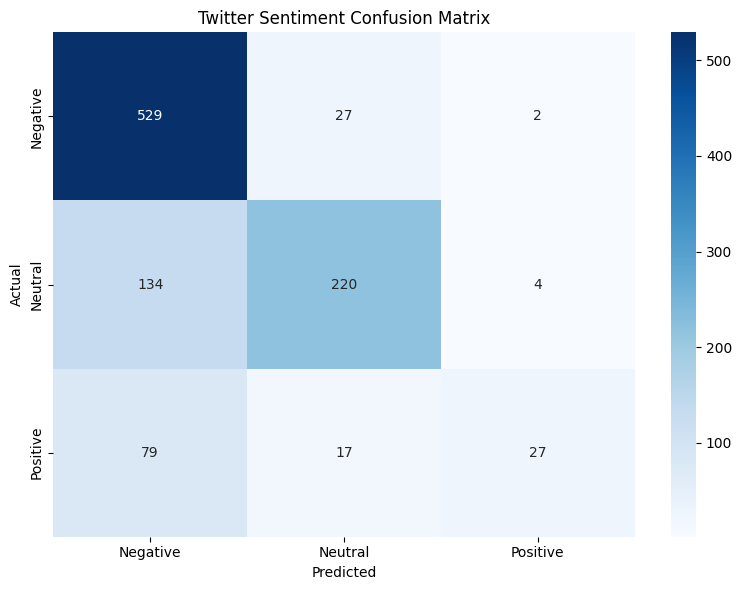

In [44]:
# Confusion matrix
cm_tw = confusion_matrix(y_test_tw, y_pred_tw)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tw, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(tweet_labels.values()),
            yticklabels=list(tweet_labels.values()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Twitter Sentiment Confusion Matrix')
plt.tight_layout()
plt.savefig('twitter_sentiment_cm.png', dpi=150)
plt.show()

### Written Question B.1 (Personal Interpretation)

Compare Amazon vs Twitter sentiment analysis:

1. **Which task was harder?** Look at the F1 scores and confusion matrices.
2. **Why did you choose those character n-gram parameters for Twitter?** What's the advantage over word n-grams?
3. **Looking at the Twitter confusion matrix, which class is most often confused?** Why might this be?
4. **Give an example tweet that would be hard to classify correctly.** Explain why.

**YOUR ANSWER:**

1. Harder task:

Amazon F1: 0.82
Twitter F1: 0.62

Reason:

Twitter sentiment analysis was more difficult than Amazon review sentiment analysis. Amazon reviews are usually longer and explicitly express positive or negative opinions, making the sentiment easier to identify. In contrast, tweets are very short, informal, and often contain slang, abbreviations, emojis, hashtags, or sarcasm. These characteristics make sentiment classification much more challenging, which explains the lower F1-score.

2. Character n-gram choices:

ngram_range = (2,5) because character n-grams capture short patterns inside words, including prefixes, suffixes, spelling variations, hashtags, and elongated words commonly found in tweets.

Advantage over words:

Character n-grams are more robust than word n-grams for social media text. They can handle spelling mistakes, abbreviations, repeated letters (e.g., soooo), hashtags, usernames, and informal writing without requiring exact word matches. This improves the model's ability to generalize to noisy Twitter data.

3. Most confused class:

Class: Positive

Reason:

The Positive class is the most frequently confused. According to the confusion matrix and the classification report, it has the lowest recall (0.22). Many positive tweets are predicted as Neutral because positive sentiment is often expressed indirectly, with irony, or using informal language that is difficult for the model to interpret.

4. Difficult tweet example:

Tweet:

"Great... another Monday morning"

Why it's hard:

Although the tweet contains the positive word "Great", the overall meaning is negative because it is sarcastic. Since the model mainly relies on textual patterns rather than understanding context or sarcasm, it may incorrectly classify the tweet as Positive or Neutral instead of Negative.

---

# PART C: Topic Modeling

We will work with two use cases:
1. **Intro:** Research Paper Topics (ArXiv)
2. **Advanced:** Legal Contract Topics

## C.1 Intro: Research Paper Topic Discovery (ArXiv)

**Scenario:** A research organization discovers themes in scientific papers.

**Method:** LDA (Latent Dirichlet Allocation)

In [50]:
# Load ArXiv papers dataset
print("Loading ArXiv papers dataset (this may take a moment)...")
arxiv = load_dataset("RimshaAIWizard/armanc_scientific_papers_arxiv_dataset")

# Sample from training set
arxiv_df = pd.DataFrame(arxiv['train']).sample(n=2000, random_state=42)

print(f"Loaded {len(arxiv_df)} papers")
print(f"Columns: {arxiv_df.columns.tolist()}")

Loading ArXiv papers dataset (this may take a moment)...
Loaded 2000 papers
Columns: ['article', 'abstract', 'section_names']


In [51]:
# Examine sample
print("Sample paper abstract (first 500 chars):")
print(arxiv_df.iloc[0]['abstract'][:500])

Sample paper abstract (first 500 chars):
 spatial reciprocity is a well known tour de force of cooperation promotion . 
 a thorough understanding of the effects of different population densities is therefore crucial . here 
 we study the evolution of cooperation in social dilemmas on different interaction graphs with a certain fraction of vacant nodes . 
 we find that sparsity may favor the resolution of social dilemmas , especially if the population density is close to the percolation threshold of the underlying graph . 
 regardless o


In [52]:
import nltk
nltk.download('punkt_tab')
# Preprocess abstracts for topic modeling
arxiv_df['abstract_clean'] = arxiv_df['abstract'].apply(preprocess_advanced)

# Create document-term matrix with CountVectorizer
count_vec_arxiv = CountVectorizer(max_features=5000)

dtm_arxiv = count_vec_arxiv.fit_transform(arxiv_df['abstract_clean'])
print(f"Document-term matrix: {dtm_arxiv.shape}")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Document-term matrix: (2000, 5000)


In [55]:
# Train LDA model
n_topics_arxiv = 10  # Scientific papers likely have diverse topics. Choose appropriately (8-12).

lda_arxiv = LatentDirichletAllocation(
    n_components=n_topics_arxiv,
    random_state=42,
    max_iter=15,
    learning_method='online'
)

print("Training LDA on ArXiv papers...")
lda_arxiv.fit(dtm_arxiv)
print("Done!")

Training LDA on ArXiv papers...
Done!


In [56]:
# Display topics
def display_lda_topics(model, feature_names, n_words=12):
    """Display top words for each LDA topic."""
    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[:-n_words-1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(f"Topic {topic_idx}: {', '.join(top_words)}")

feature_names_arxiv = count_vec_arxiv.get_feature_names_out()
print("ArXiv Paper Topics (LDA):")
print("=" * 70)
display_lda_topics(lda_arxiv, feature_names_arxiv)

ArXiv Paper Topics (LDA):
Topic 0: method, algorithm, solution, error, equation, problem, space, theory, function, new, show, set
Topic 1: metal, surface, film, spp, spider, protein, emf, soliton, wire, thin, island, thz
Topic 2: graph, france, modulus, fabry, cedex, afm, charles, sic, laboratoire, orsay, linstitut, doptique
Topic 3: xmath, galaxy, mass, model, cluster, star, energy, formation, data, result, density, find
Topic 4: xmath, xcite, model, state, energy, field, system, value, one, function, result, two
Topic 5: state, quantum, system, two, spin, frequency, field, wave, effect, interaction, photon, xcite
Topic 6: network, model, system, data, link, structure, result, based, paper, performance, dynamic, node
Topic 7: xmath, ray, star, emission, source, observation, spectrum, high, disk, line, flux, region
Topic 8: neutrino, mass, decay, physic, quark, experiment, higgs, university, production, model, gev, energy
Topic 9: rate, integral, channel, flow, time, energy, protocol, 

### Exercise C.1: Interpret ArXiv Topics

In [58]:
# TODO: Assign meaningful labels to each topic based on the keywords

my_arxiv_topic_labels = {
    0: "Méthodologie et résolution de problèmes",  # method, algorithm, solution, error, equation, problem
    1: "Physique des matériaux",  # metal, surface, film, protein, wire, thin
    2: "Optique et Physique Expérimentale",  # graph, modulus, fabry, cedex, orsay, linstitut
    3: "Astrophysique et Cosmologie",  # galaxy, mass, model, cluster, star, energy, formation, data
    4: "Modélisation et Systèmes Théoriques",  # model, state, energy, system, value, function, result
    5: "Physique Quantique et Interaction",  # quantum, system, spin, frequency, field, wave, effect, interaction, photon
    6: "Réseaux et Analyse de Données",  # network, model, system, data, link, structure, performance
    7: "Astronomie d'Observation",  # ray, star, emission, source, observation, spectrum, high, disk
    8: "Physique des Particules",  # neutrino, mass, decay, physic, quark, experiment, higgs, production, energy
    9: "Dynamique des Fluides et Systèmes Énergétiques"  # rate, integral, channel, flow, time, energy, power, distribution
}

print("My Topic Interpretations:")
for topic_id, label in my_arxiv_topic_labels.items():
    if label != "___":
        print(f"  Topic {topic_id}: {label}")

My Topic Interpretations:
  Topic 0: Méthodologie et résolution de problèmes
  Topic 1: Physique des matériaux
  Topic 2: Optique et Physique Expérimentale
  Topic 3: Astrophysique et Cosmologie
  Topic 4: Modélisation et Systèmes Théoriques
  Topic 5: Physique Quantique et Interaction
  Topic 6: Réseaux et Analyse de Données
  Topic 7: Astronomie d'Observation
  Topic 8: Physique des Particules
  Topic 9: Dynamique des Fluides et Systèmes Énergétiques


## C.2 Advanced: Legal Contract Topic Discovery

**Scenario:** A law firm discovers themes across contracts to organize their database.

**Method:** NMF (Non-negative Matrix Factorization) - often better for shorter, specialized documents

**Challenge:** Legal language is formal and domain-specific.

In [59]:
# Load legal contracts dataset (streaming to handle large size)
print("Loading Legal Contracts dataset...")
legal_stream = load_dataset("albertvillanova/legal_contracts", split="train", streaming=True, trust_remote_code=True)

# Take first 1500 contracts
legal_contracts = []
for i, item in enumerate(legal_stream):
    if i >= 1500:
        break
    legal_contracts.append(item)

legal_df = pd.DataFrame(legal_contracts)
print(f"Loaded {len(legal_df)} contracts")

Loading Legal Contracts dataset...


legal_contracts.py:   0%|          | 0.00/2.50k [00:00<?, ?B/s]

Loaded 1500 contracts


In [61]:
# Preprocess legal text (truncate long documents)
legal_df['text_truncated'] = legal_df['text'].str[:8000]  # Truncate
legal_df['text_clean'] = legal_df['text_truncated'].apply(preprocess_advanced)

print("Sample contract (cleaned, first 300 chars):")
print(legal_df.iloc[0]['text_clean'][:300])

Sample contract (cleaned, first 300 chars):
quicklinks click rapidly navigate document amended restated employment noncompetition agreement amended restated employment noncompetition agreement agreement made entered october among avocent employment service formerly known polycon investment inc texas corporation employer avocent corporation de


### Exercise C.2: Build NMF Topic Model for Legal Contracts

In [62]:
# TODO: Create TF-IDF vectorizer for NMF (NMF works better with TF-IDF)

tfidf_legal = TfidfVectorizer(max_features=5000) # Initialisation du TfidfVectorizer

dtm_legal = tfidf_legal.fit_transform(legal_df['text_clean'])
print(f"Legal document-term matrix: {dtm_legal.shape}")

Legal document-term matrix: (1500, 5000)


In [64]:
# TODO: Train NMF model
# Choose number of topics (legal contracts may have: employment, confidentiality, IP, services, etc.)

n_topics_legal = 8  # YOUR CHOICE: 5-12

nmf_legal = NMF(
    n_components=n_topics_legal,
    random_state=42,
    max_iter=200
)

print(f"Training NMF with {n_topics_legal} topics...")
nmf_legal.fit(dtm_legal)
print("Done!")

Training NMF with 8 topics...
Done!


In [65]:
# Display NMF topics
def display_nmf_topics(model, feature_names, n_words=12):
    """Display top words for each NMF topic."""
    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[:-n_words-1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(f"Topic {topic_idx}: {', '.join(top_words)}")

feature_names_legal = tfidf_legal.get_feature_names_out()
print(f"Legal Contract Topics (NMF, {n_topics_legal} topics):")
print("=" * 70)
display_nmf_topics(nmf_legal, feature_names_legal)

Legal Contract Topics (NMF, 8 topics):
Topic 0: executive, company, employment, shall, agreement, benefit, salary, termination, base, bonus, date, compensation
Topic 1: borrower, loan, credit, lender, agreement, bank, amendment, agent, section, amended, revolving, administrative
Topic 2: option, plan, stock, share, committee, participant, award, shall, mean, common, granted, director
Topic 3: employee, employment, company, agreement, shall, termination, employer, bonus, salary, benefit, term, year
Topic 4: seller, buyer, agreement, purchase, purchaser, share, closing, shall, aircraft, property, schedule, party
Topic 5: tenant, landlord, lease, rent, premise, lessee, building, lessor, shall, term, floor, improvement
Topic 6: note, maker, principal, interest, shall, rate, holder, due, payment, unpaid, amount, payee
Topic 7: company, voting, security, director, control, change, board, person, corporation, combination, outstanding, election


In [67]:
# TODO: Assign labels to legal topics

my_legal_topic_labels = {
    0: "Contrats de travail et rémunération",  # executive, employment, salary, bonus, compensation
    1: "Accords de prêt et de crédit",  # borrower, loan, credit, lender, bank
    2: "Plans d'options d'achat d'actions",  # option, plan, stock, share, committee, award
    3: "Contrats d'emploi et de cessation",  # employee, employment, termination, employer, benefit
    4: "Accords d'achat et de vente",  # seller, buyer, agreement, purchase, property
    5: "Contrats de location immobilière",  # tenant, landlord, lease, rent, premise
    6: "Billets à ordre et paiement",  # note, maker, principal, interest, payment
    7: "Gouvernance d'entreprise et droits de vote"  # company, voting, security, director, board
}

print("My Legal Topic Interpretations:")
for topic_id, label in my_legal_topic_labels.items():
    if label != "___":
        print(f"  Topic {topic_id}: {label}")

My Legal Topic Interpretations:
  Topic 0: Contrats de travail et rémunération
  Topic 1: Accords de prêt et de crédit
  Topic 2: Plans d'options d'achat d'actions
  Topic 3: Contrats d'emploi et de cessation
  Topic 4: Accords d'achat et de vente
  Topic 5: Contrats de location immobilière
  Topic 6: Billets à ordre et paiement
  Topic 7: Gouvernance d'entreprise et droits de vote


### Exercise C.3: Topic Distribution Visualization

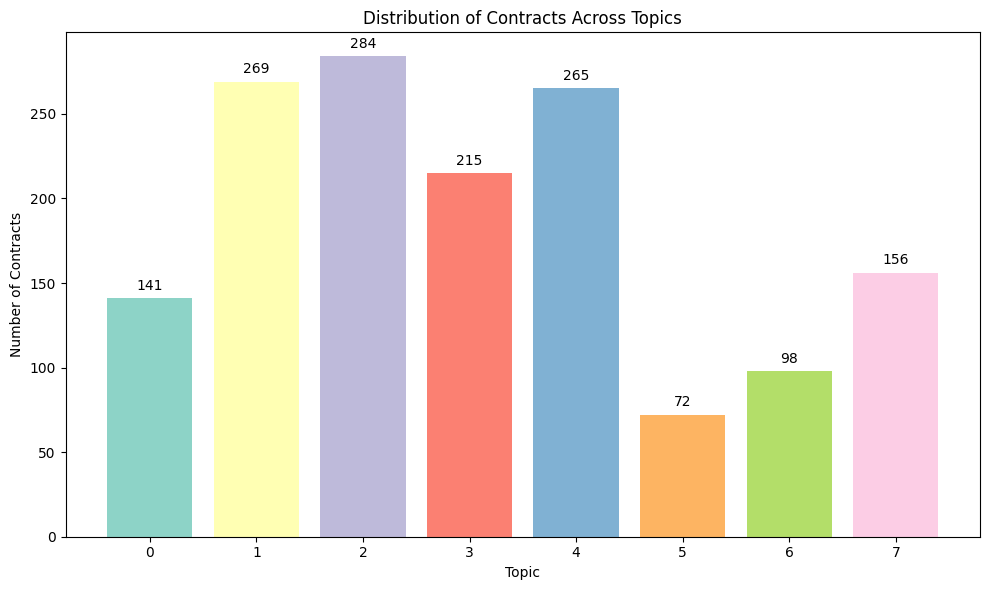

In [68]:
# Get document-topic distributions
doc_topics_legal = nmf_legal.transform(dtm_legal)

# Assign dominant topic
legal_df['dominant_topic'] = doc_topics_legal.argmax(axis=1)

# Visualize topic distribution
plt.figure(figsize=(10, 6))
topic_counts = legal_df['dominant_topic'].value_counts().sort_index()
bars = plt.bar(topic_counts.index, topic_counts.values, color=plt.cm.Set3(range(len(topic_counts))))
plt.xlabel('Topic')
plt.ylabel('Number of Contracts')
plt.title('Distribution of Contracts Across Topics')
plt.xticks(range(n_topics_legal))

# Add count labels
for bar, count in zip(bars, topic_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('legal_topic_distribution.png', dpi=150)
plt.show()

### Written Question C.1 (Personal Interpretation)

Compare ArXiv (LDA) vs Legal Contracts (NMF) topic modeling:

1. **Which set of topics was easier to interpret?** Why?
2. **Looking at the legal topic distribution, is it balanced?** What does this tell you about the contract dataset?
3. **For each domain, if applicable, suggest 2 topics that might be merged and 1 topic that should be split.** Justify.

**YOUR ANSWER:**

1. Easier to interpret:

Domain: Legal Contracts (NMF)

Reason:
The legal contract topics were easier to interpret because each topic is centered on a specific type of contract or legal agreement. For example, the model clearly identified topics related to employment contracts, loans, leases, purchase agreements, and stock option plans. In contrast, several ArXiv topics contain generic scientific terms such as model, system, energy, or data, which appear across many research fields, making some topics overlap and harder to distinguish.

2. Legal topic distribution:

Balanced?
The distribution is reasonably balanced, although a few topics contain more documents than others.
What this indicates:
This suggests that the contract dataset contains several major categories of legal agreements rather than being dominated by a single contract type. However, the differences in topic sizes indicate that some contract types (such as employment or financial agreements) are more common than others.

3. Topic refinement suggestions:

ArXiv – Merge: Topics 3 and 7 because both focus on astrophysics and astronomy, with keywords such as galaxy, star, emission, spectrum, and observation. They represent closely related research areas and could be combined into a broader astronomy topic.
ArXiv – Split: Topic 6 because it mixes concepts related to networks, systems, data, performance, and dynamic models, which could correspond to different research fields such as computer science and systems engineering.
Legal – Merge: Topics 0 and 3 because both describe employment agreements, including keywords such as employment, employee, salary, bonus, termination, and benefit. They represent very similar legal concepts and could form a single employment contract topic.
Legal – Split: Topic 4 because it combines several types of purchase agreements, including terms related to seller, buyer, property, and aircraft. These could be separated into more specific topics, such as real estate transactions and commercial asset sales.

---

## Summary - Lab 4 Part 2

### Methods Summary

| Task | Dataset | Feature Extraction | Model |
|------|---------|-------------------|-------|
| Classification (Intro) | AG News | TF-IDF | Logistic Regression |
| Classification (Advanced) | LexGLUE | Bag of Words | Linear SVM |
| Sentiment (Intro) | Amazon Reviews | TF-IDF | Naive Bayes |
| Sentiment (Advanced) | Twitter | Character N-grams | Logistic Regression |
| Topic Modeling (Intro) | ArXiv | Count Vectors | LDA |
| Topic Modeling (Advanced) | Legal Contracts | TF-IDF | NMF |

### Key Takeaways

- **Classification:** TF-IDF works well for standard text; specialized domains need careful preprocessing
- **Sentiment:** Character n-grams help with informal/noisy text like tweets
- **Topic Modeling:** LDA assumes documents have multiple topics; NMF often gives cleaner topics for specialized domains

---

## Submission Checklist

- [ ] All code exercises completed (fill all `___` placeholders)
- [ ] **All written questions answered with YOUR personal interpretation**
- [ ] All visualizations saved (PNG files)
- [ ] Notebook saved
- [ ] Pushed to Git repository
- [ ] **Repository link sent to: yoroba93@gmail.com**
